In [ ]:
## 데이터 전처리 및 정렬 ##

#✅ 1. GTF 압축 해제
!gunzip gencode.vM37.annotation.gtf.gz

In [ ]:
#✅ 2. bowtie2 설치
!sudo apt install bowtie2
# → rRNA 제거를 위해 bowtie2 정렬 도구 설치

In [ ]:
#✅ 3. 마우스 rRNA 서열을 인덱싱 (rRNA 제거용)
!bowtie2-build mouse_rRNA.fa rRna_index
# → rRNA 시퀀스를 인덱스로 변환해서 bowtie2로 검색 가능하게 준비

In [ ]:
#✅ 4. 유전체 FASTA 압축 해제
!gunzip GRCm39.primary_assembly.genome.fa.gz

In [12]:
#✅ 5. GRCm39 유전체 HISAT2 인덱스 생성
!hisat2-build GRCm39.primary_assembly.genome.fa GRCm39.primary_assembly.genome_index

Settings:
  Output files: "GRCm39.primary_assembly.genome_index.*.ht2"
  Line rate: 6 (line is 64 bytes)
  Lines per side: 1 (side is 64 bytes)
  Offset rate: 4 (one in 16)
  FTable chars: 10
  Strings: unpacked
  Local offset rate: 3 (one in 8)
  Local fTable chars: 6
  Local sequence length: 57344
  Local sequence overlap between two consecutive indexes: 1024
  Endianness: little
  Actual local endianness: little
  Sanity checking: disabled
  Assertions: disabled
  Random seed: 0
  Sizeofs: void*:8, int:4, long:8, size_t:8
Input files DNA, FASTA:
  GRCm39.primary_assembly.genome.fa
Reading reference sizes
  Time reading reference sizes: 00:00:33
Calculating joined length
Writing header
Reserving space for joined string
Joining reference sequences
  Time to join reference sequences: 00:00:19
  Time to read SNPs and splice sites: 00:00:00
Using parameters --bmax 497741584 --dcv 1024
  Doing ahead-of-time memory usage test
  Passed!  Constructing with these parameters: --bmax 497741584 

In [ ]:
# Exercise ✅ 6. Exercise 데이터 FASTQ 압축 해제 단계
!gunzip SRR2057648.fastq.gz

In [1]:
# Contorl ✅ 6. Control 데이터 FASTQ 압축 해제 단계
!gunzip SRR2057646.fastq.gz

In [ ]:
# Exercise mRNA ✅ 6. Exercise 데이터 FASTQ 압축 해제 단계
!gunzip SRR2057644.fastq.gz

In [76]:
# Contorl mRNA ✅ 6. Control 데이터 FASTQ 압축 해제 단계
!gunzip SRR2057642.fastq.gz

In [39]:
#Exercise ✅ 7. fastp를 이용한 read 품질 필터링 (trimming)
import subprocess

subprocess.run([
    "fastp",
    "-i", "SRR2057648.fastq",
    "-o", "trimmed_SRR2057648.fastq",
    "-q", "20",
    "-l", "25",
    "-h", "fastp_report_exercise.html"
])
# → 낮은 품질의 read를 제거하고, 분석에 적합한 read만 추림

Detecting adapter sequence for read1...
AGGGCACCACCAGGAGTGGAGCCTGCGGCTTAATTTG

Read1 before filtering:
total reads: 3565792
total bases: 104708331
Q20 bases: 99050272(94.5964%)
Q30 bases: 99050272(94.5964%)

Read1 after filtering:
total reads: 3333170
total bases: 97963669
Q20 bases: 97963669(100%)
Q30 bases: 97963669(100%)

Filtering result:
reads passed filter: 3333170
reads failed due to low quality: 188207
reads failed due to too many N: 0
reads failed due to too short: 44415
reads with adapter trimmed: 8364
bases trimmed due to adapters: 63266

Duplication rate (may be overestimated since this is SE data): 25.1515%

JSON report: fastp.json
HTML report: fastp_report_exercise.html

fastp -i SRR2057648.fastq -o trimmed_SRR2057648.fastq -q 20 -l 25 -h fastp_report_exercise.html 
fastp v0.20.1, time used: 6 seconds


CompletedProcess(args=['fastp', '-i', 'SRR2057648.fastq', '-o', 'trimmed_SRR2057648.fastq', '-q', '20', '-l', '25', '-h', 'fastp_report_exercise.html'], returncode=0)

In [2]:
#Control ✅ 7. fastp를 이용한 read 품질 필터링 (trimming)
import subprocess

subprocess.run([
    "fastp",
    "-i", "SRR2057646.fastq",
    "-o", "trimmed_SRR2057646.fastq",
    "-q", "20",
    "-l", "25",
    "-h", "fastp_report_contrl.html"
])
# → 낮은 품질의 read를 제거하고, 분석에 적합한 read만 추림

Detecting adapter sequence for read1...
No adapter detected for read1

Read1 before filtering:
total reads: 2743301
total bases: 82639361
Q20 bases: 75746021(91.6585%)
Q30 bases: 75746021(91.6585%)

Read1 after filtering:
total reads: 2498635
total bases: 75292037
Q20 bases: 75292037(100%)
Q30 bases: 75292037(100%)

Filtering result:
reads passed filter: 2498635
reads failed due to low quality: 225750
reads failed due to too many N: 0
reads failed due to too short: 18916
reads with adapter trimmed: 0
bases trimmed due to adapters: 0

Duplication rate (may be overestimated since this is SE data): 18.6644%

JSON report: fastp.json
HTML report: fastp_report_contrl.html

fastp -i SRR2057646.fastq -o trimmed_SRR2057646.fastq -q 20 -l 25 -h fastp_report_contrl.html 
fastp v0.20.1, time used: 4 seconds


CompletedProcess(args=['fastp', '-i', 'SRR2057646.fastq', '-o', 'trimmed_SRR2057646.fastq', '-q', '20', '-l', '25', '-h', 'fastp_report_contrl.html'], returncode=0)

In [77]:
#Control mRNA ✅ 7. fastp를 이용한 read 품질 필터링 (trimming)
import subprocess

subprocess.run([
    "fastp",
    "-i", "SRR2057642.fastq",
    "-o", "trimmed_SRR2057642.fastq",
    "-q", "20",
    "-l", "25",
    "-h", "fastp_report_contrl.html"
])
# → 낮은 품질의 read를 제거하고, 분석에 적합한 read만 추림

Detecting adapter sequence for read1...
CGGTCATGGTGTATTTGCCCTTAAGCACGGCAGAAACTGCCTGCATCTC

Read1 before filtering:
total reads: 1697188
total bases: 56108950
Q20 bases: 48530859(86.494%)
Q30 bases: 48530859(86.494%)

Read1 after filtering:
total reads: 1398994
total bases: 46654080
Q20 bases: 46654080(100%)
Q30 bases: 46654080(100%)

Filtering result:
reads passed filter: 1398994
reads failed due to low quality: 228895
reads failed due to too many N: 0
reads failed due to too short: 69299
reads with adapter trimmed: 17915
bases trimmed due to adapters: 657879

Duplication rate (may be overestimated since this is SE data): 5.10387%

JSON report: fastp.json
HTML report: fastp_report_contrl.html

fastp -i SRR2057642.fastq -o trimmed_SRR2057642.fastq -q 20 -l 25 -h fastp_report_contrl.html 
fastp v0.20.1, time used: 3 seconds


CompletedProcess(args=['fastp', '-i', 'SRR2057642.fastq', '-o', 'trimmed_SRR2057642.fastq', '-q', '20', '-l', '25', '-h', 'fastp_report_contrl.html'], returncode=0)

In [ ]:
#Exercise mRNA ✅ 7. fastp를 이용한 read 품질 필터링 (trimming)
import subprocess

subprocess.run([
    "fastp",
    "-i", "SRR2057644.fastq",
    "-o", "trimmed_SRR2057644.fastq",
    "-q", "20",
    "-l", "25",
    "-h", "fastp_report_contrl.html"
])
# → 낮은 품질의 read를 제거하고, 분석에 적합한 read만 추림

In [40]:
#Exercise ✅ 8. rRNA read 제거: bowtie2로 정렬되지 않은 read만 추출 
!bowtie2 -x rRna_index -U trimmed_SRR2057648.fastq -S SRR2057648_rRNA.sam --un non_rRNA_SRR2057648.fastq
# → rRNA 인덱스에 정렬 시도
# → 정렬되지 않은 read (즉, rRNA가 아닌 read)를 non_rRNA_SRR2057648.fastq에 저장

3333170 reads; of these:
  3333170 (100.00%) were unpaired; of these:
    3314684 (99.45%) aligned 0 times
    89 (0.00%) aligned exactly 1 time
    18397 (0.55%) aligned >1 times
0.55% overall alignment rate


In [3]:
#Contorl ✅ 8. rRNA read 제거: bowtie2로 정렬되지 않은 read만 추출 
!bowtie2 -x rRna_index -U trimmed_SRR2057646.fastq -S SRR2057646_rRNA.sam --un non_rRNA_SRR2057646.fastq
# → rRNA 인덱스에 정렬 시도
# → 정렬되지 않은 read (즉, rRNA가 아닌 read)를 non_rRNA_SRR2057646.fastq에 저장

2498635 reads; of these:
  2498635 (100.00%) were unpaired; of these:
    2483334 (99.39%) aligned 0 times
    147 (0.01%) aligned exactly 1 time
    15154 (0.61%) aligned >1 times
0.61% overall alignment rate


In [78]:
#Contorl mRNA ✅ 8. rRNA read 제거: bowtie2로 정렬되지 않은 read만 추출 
!bowtie2 -x rRna_index -U trimmed_SRR2057642.fastq -S SRR2057642_rRNA.sam --un non_rRNA_SRR2057642.fastq
# → rRNA 인덱스에 정렬 시도
# → 정렬되지 않은 read (즉, rRNA가 아닌 read)를 non_rRNA_SRR2057642.fastq에 저장

1398994 reads; of these:
  1398994 (100.00%) were unpaired; of these:
    1398485 (99.96%) aligned 0 times
    78 (0.01%) aligned exactly 1 time
    431 (0.03%) aligned >1 times
0.04% overall alignment rate


In [46]:
#Exercise mRNA ✅ 8. rRNA 제거된 Ribo-seq read를 GRCm39에 정렬
!hisat2 -p 8 -x GRCm39.primary_assembly.genome_index -U  non_rRNA_SRR2057648.fastq -S SRR2057648.mapped.sam

3314684 reads; of these:
  3314684 (100.00%) were unpaired; of these:
    1009257 (30.45%) aligned 0 times
    1430090 (43.14%) aligned exactly 1 time
    875337 (26.41%) aligned >1 times
69.55% overall alignment rate


In [4]:
#Control ✅ 8. rRNA 제거된 Ribo-seq read를 GRCm39에 정렬
!hisat2 -p 8 -x GRCm39.primary_assembly.genome_index -U  non_rRNA_SRR2057646.fastq -S SRR2057646.mapped.sam

2483334 reads; of these:
  2483334 (100.00%) were unpaired; of these:
    983725 (39.61%) aligned 0 times
    995688 (40.09%) aligned exactly 1 time
    503921 (20.29%) aligned >1 times
60.39% overall alignment rate


In [85]:
#Control ✅ 8. rRNA 제거된 Ribo-seq read를 GRCm39에 정렬
!hisat2 -p 8 -x GRCm39.primary_assembly.genome_index -U  non_rRNA_SRR2057642.fastq -S SRR2057642.mapped.sam

1398485 reads; of these:
  1398485 (100.00%) were unpaired; of these:
    1024851 (73.28%) aligned 0 times
    267916 (19.16%) aligned exactly 1 time
    105718 (7.56%) aligned >1 times
26.72% overall alignment rate


In [48]:
#Exercise ✅ 9. SAM 파일을 BAM 형식으로 정렬 및 변환
!samtools sort -@ 4 \-o SRR2057648.mapped.sorted.bam \SRR2057648.mapped.sam

[bam_sort_core] merging from 0 files and 4 in-memory blocks...


In [5]:
#Control ✅ 9. SAM 파일을 BAM 형식으로 정렬 및 변환
!samtools sort -@ 4 \-o SRR2057646.mapped.sorted.bam \SRR2057646.mapped.sam

[bam_sort_core] merging from 0 files and 4 in-memory blocks...


In [92]:
#Control mRNA✅ 9. SAM 파일을 BAM 형식으로 정렬 및 변환
!samtools sort -@ 4 -o SRR2057642.mapped.sorted.bam SRR2057642.mapped.sam

[bam_sort_core] merging from 0 files and 4 in-memory blocks...


In [ ]:
#Control mRNA✅ 9. SAM 파일을 BAM 형식으로 정렬 및 변환
!samtools sort -@ 4 -o SRR2057644.mapped.sorted.bam SRR2057644.mapped.sam

In [49]:
!ls -lh SRR2057648.mapped.sorted.bam

-rwxrwxrwx 1 moon moon 42M Jun  6 00:34 SRR2057648.mapped.sorted.bam


In [89]:
!ls -lh SRR2057646.mapped.sorted.bam

-rwxrwxrwx 1 moon moon 30M Jun  6 17:00 SRR2057646.mapped.sorted.bam


In [93]:
!ls -lh SRR2057642.mapped.sorted.bam

-rwxrwxrwx 1 moon moon 20M Jun 12 12:49 SRR2057642.mapped.sorted.bam


In [1]:
!ls -lh SRR2057644.mapped.sorted.bam

-rwxrwxrwx 1 moon moon 41M Jun 11 18:44 SRR2057644.mapped.sorted.bam


In [50]:
#Exercise ✅ 10. 정렬된 BAM 파일 확인
!samtools flagstat SRR2057648.mapped.sorted.bam

5241407 + 0 in total (QC-passed reads + QC-failed reads)
3314684 + 0 primary
1926723 + 0 secondary
0 + 0 supplementary
0 + 0 duplicates
0 + 0 primary duplicates
4232150 + 0 mapped (80.74% : N/A)
2305427 + 0 primary mapped (69.55% : N/A)
0 + 0 paired in sequencing
0 + 0 read1
0 + 0 read2
0 + 0 properly paired (N/A : N/A)
0 + 0 with itself and mate mapped
0 + 0 singletons (N/A : N/A)
0 + 0 with mate mapped to a different chr
0 + 0 with mate mapped to a different chr (mapQ>=5)


In [7]:
#Contorl ✅ 10. 정렬된 BAM 파일 확인
!samtools flagstat SRR2057646.mapped.sorted.bam

3488955 + 0 in total (QC-passed reads + QC-failed reads)
2483334 + 0 primary
1005621 + 0 secondary
0 + 0 supplementary
0 + 0 duplicates
0 + 0 primary duplicates
2505230 + 0 mapped (71.80% : N/A)
1499609 + 0 primary mapped (60.39% : N/A)
0 + 0 paired in sequencing
0 + 0 read1
0 + 0 read2
0 + 0 properly paired (N/A : N/A)
0 + 0 with itself and mate mapped
0 + 0 singletons (N/A : N/A)
0 + 0 with mate mapped to a different chr
0 + 0 with mate mapped to a different chr (mapQ>=5)


In [94]:
#Contorl mRNA ✅ 10. 정렬된 BAM 파일 확인
!samtools flagstat SRR2057642.mapped.sorted.bam

1573594 + 0 in total (QC-passed reads + QC-failed reads)
1398485 + 0 primary
175109 + 0 secondary
0 + 0 supplementary
0 + 0 duplicates
0 + 0 primary duplicates
548743 + 0 mapped (34.87% : N/A)
373634 + 0 primary mapped (26.72% : N/A)
0 + 0 paired in sequencing
0 + 0 read1
0 + 0 read2
0 + 0 properly paired (N/A : N/A)
0 + 0 with itself and mate mapped
0 + 0 singletons (N/A : N/A)
0 + 0 with mate mapped to a different chr
0 + 0 with mate mapped to a different chr (mapQ>=5)


In [ ]:
#Contorl mRNA ✅ 10. 정렬된 BAM 파일 확인
!samtools flagstat SRR2057644.mapped.sorted.bam

In [32]:
#✅ 11. GTF 파일 압축 해제
!gunzip gencode.vM37.annotation.gtf.gz

In [7]:
#Exercise ✅ 12. featureCounts로 gene별 read 수 계산
!featureCounts \-a gencode.vM37.annotation.gtf \-o SRR2057648_read_counts.txt \SRR2057648.mapped.sorted.bam


        ==========     _____ _    _ ____  _____  ______          _____  
        =====         / ____| |  | |  _ \|  __ \|  ____|   /\   |  __ \ 
          =====      | (___ | |  | | |_) | |__) | |__     /  \  | |  | |
            ====      \___ \| |  | |  _ <|  _  /|  __|   / /\ \ | |  | |
              ====    ____) | |__| | |_) | | \ \| |____ / ____ \| |__| |
        ==========   |_____/ \____/|____/|_|  \_\______/_/    \_\_____/
	  v2.0.1

//========================== featureCounts setting ===========================\\
||                                                                            ||
||             Input files : 1 BAM file                                       ||
||                           o SRR2057648.mapped.sorted.bam                   ||
||                                                                            ||
||             Output file : SRR2057648_read_counts.txt                       ||
||                 Summary : SRR2057648_read_counts.txt.summary  

In [8]:
#Control ✅ 12. featureCounts로 gene별 read 수 계산
!featureCounts \-a gencode.vM37.annotation.gtf \-o SRR2057646_read_counts.txt \SRR2057646.mapped.sorted.bam


        ==========     _____ _    _ ____  _____  ______          _____  
        =====         / ____| |  | |  _ \|  __ \|  ____|   /\   |  __ \ 
          =====      | (___ | |  | | |_) | |__) | |__     /  \  | |  | |
            ====      \___ \| |  | |  _ <|  _  /|  __|   / /\ \ | |  | |
              ====    ____) | |__| | |_) | | \ \| |____ / ____ \| |__| |
        ==========   |_____/ \____/|____/|_|  \_\______/_/    \_\_____/
	  v2.0.1

//========================== featureCounts setting ===========================\\
||                                                                            ||
||             Input files : 1 BAM file                                       ||
||                           o SRR2057646.mapped.sorted.bam                   ||
||                                                                            ||
||             Output file : SRR2057646_read_counts.txt                       ||
||                 Summary : SRR2057646_read_counts.txt.summary  

In [96]:
#Exercise mRNA ✅ 12. featureCounts로 gene별 read 수 계산
!featureCounts \-a gencode.vM37.annotation.gtf \-o SRR2057644_read_counts.txt \SRR2057644.mapped.sorted.bam


        ==========     _____ _    _ ____  _____  ______          _____  
        =====         / ____| |  | |  _ \|  __ \|  ____|   /\   |  __ \ 
          =====      | (___ | |  | | |_) | |__) | |__     /  \  | |  | |
            ====      \___ \| |  | |  _ <|  _  /|  __|   / /\ \ | |  | |
              ====    ____) | |__| | |_) | | \ \| |____ / ____ \| |__| |
        ==========   |_____/ \____/|____/|_|  \_\______/_/    \_\_____/
	  v2.0.1

//========================== featureCounts setting ===========================\\
||                                                                            ||
||             Input files : 1 BAM file                                       ||
||                           o SRR2057644.mapped.sorted.bam                   ||
||                                                                            ||
||             Output file : SRR2057644_read_counts.txt                       ||
||                 Summary : SRR2057644_read_counts.txt.summary  

In [95]:
#Control mRNA ✅ 12. featureCounts로 gene별 read 수 계산
!featureCounts \-a gencode.vM37.annotation.gtf \-o SRR2057642_read_counts.txt \SRR2057642.mapped.sorted.bam


        ==========     _____ _    _ ____  _____  ______          _____  
        =====         / ____| |  | |  _ \|  __ \|  ____|   /\   |  __ \ 
          =====      | (___ | |  | | |_) | |__) | |__     /  \  | |  | |
            ====      \___ \| |  | |  _ <|  _  /|  __|   / /\ \ | |  | |
              ====    ____) | |__| | |_) | | \ \| |____ / ____ \| |__| |
        ==========   |_____/ \____/|____/|_|  \_\______/_/    \_\_____/
	  v2.0.1

//========================== featureCounts setting ===========================\\
||                                                                            ||
||             Input files : 1 BAM file                                       ||
||                           o SRR2057642.mapped.sorted.bam                   ||
||                                                                            ||
||             Output file : SRR2057642_read_counts.txt                       ||
||                 Summary : SRR2057642_read_counts.txt.summary  

In [130]:
import pandas as pd
import numpy as np

# 🔹 featureCounts 파일 불러오기
def load_counts(file_path):
    return pd.read_csv(file_path, sep='\t', comment='#', index_col=0)

rpf_ex = load_counts("SRR2057648_read_counts.txt")
rpf_ctrl = load_counts("SRR2057646_read_counts.txt")
rna_ex = load_counts("SRR2057644_read_counts.txt")
rna_ctrl = load_counts("SRR2057642_read_counts.txt")

# 🔹 CPM 계산 함수
def compute_cpm(df):
    counts = df.iloc[:, -1]  # 마지막 열이 count
    cpm = (counts / counts.sum()) * 1e6
    return cpm

rpf_ex_cpm = compute_cpm(rpf_ex)
rpf_ctrl_cpm = compute_cpm(rpf_ctrl)
rna_ex_cpm = compute_cpm(rna_ex)
rna_ctrl_cpm = compute_cpm(rna_ctrl)

# 🔹 유효 유전자 필터링: 모든 조건에서 CPM > 1
valid_genes = (
    (rpf_ex_cpm > 1.0) &
    (rpf_ctrl_cpm > 1.0) &
    (rna_ex_cpm > 1.0) &
    (rna_ctrl_cpm > 1.0)
)

# 🔹 작은 값 방지용
epsilon = 1e-6

# 🔹 TE 및 rden_change 계산 (유효 유전자만)
exercise_te = (rpf_ex_cpm[valid_genes] + epsilon) / (rna_ex_cpm[valid_genes] + epsilon)
control_te = (rpf_ctrl_cpm[valid_genes] + epsilon) / (rna_ctrl_cpm[valid_genes] + epsilon)
rden_change = exercise_te / control_te

# 🔹 결과 데이터프레임 생성
rden_df = pd.DataFrame({
    'exercise_TE': exercise_te,
    'control_TE': control_te,
    'rden_change': rden_change,
})
rden_df.index.name = 'gene_id'
rden_df['log2_rden_change'] = np.log2(rden_df['rden_change'] + epsilon)

In [97]:
import pandas as pd

# featureCounts 파일 불러오기 (주석줄 건너뛰기, gene ID 기준)
def load_counts(file_path):
    return pd.read_csv(file_path, sep='\t', comment='#', index_col=0)

rpf_ex = load_counts("SRR2057648_read_counts.txt")
rpf_ctrl = load_counts("SRR2057646_read_counts.txt")
rna_ex = load_counts("SRR2057644_read_counts.txt")
rna_ctrl = load_counts("SRR2057642_read_counts.txt")

In [98]:
def compute_cpm(df):
    total_counts = df['Length'].sum()  # 또는 df.iloc[:,5].sum()로 count 열 직접 선택
    cpm = (df.iloc[:, -1] / df.iloc[:, -1].sum()) * 1e6
    return cpm

In [99]:
rpf_ex_cpm = compute_cpm(rpf_ex)
rpf_ctrl_cpm = compute_cpm(rpf_ctrl)
rna_ex_cpm = compute_cpm(rna_ex)
rna_ctrl_cpm = compute_cpm(rna_ctrl)

In [100]:
# 작은 값 추가로 0 나눗셈 방지
epsilon = 1e-6

exercise_te = (rpf_ex_cpm + epsilon) / (rna_ex_cpm + epsilon)
control_te = (rpf_ctrl_cpm + epsilon) / (rna_ctrl_cpm + epsilon)

rden_change = exercise_te / control_te

# 결과 데이터프레임으로 정리
rden_df = pd.DataFrame({
    'exercise_TE': exercise_te,
    'control_TE': control_te,
    'rden_change': rden_change
})
rden_df.index.name = 'gene_id'

In [101]:
rden_df['log2_rden_change'] = np.log2(rden_df['rden_change'])

In [131]:
rden_df.head()

,exercise_TE,control_TE,rden_change,log2_rden_change
gene_id,,,,
ENSMUSG00000025902.14,2.450525,0.260173,9.418834,3.235549
ENSMUSG00000033845.14,0.394807,0.130086,3.034960,1.601678
ENSMUSG00000025903.15,0.025795,0.015304,1.685476,0.753157
ENSMUSG00000033793.13,0.980210,0.303535,3.229317,1.691229
ENSMUSG00000025907.15,1.116350,0.411940,2.709982,1.438284


In [ ]:
import pandas as pd
from mygene import MyGeneInfo

# 1️⃣ Uniprot localization 데이터 불러오기
uniprot_df = pd.read_csv("uniprotkb_Mus_musculus_Mouse_2025_06_05.tsv", sep='\t')

# 2️⃣ Gene Symbol 정리 후 필요한 데이터 선택
uniprot_genes = uniprot_df[['Gene Names', 'Subcellular location [CC]']].copy()
uniprot_genes.rename(columns={'Gene Names': 'symbol'}, inplace=True)
uniprot_genes['symbol'] = uniprot_genes['symbol'].str.split().str[0]  # 첫 번째 심볼만 선택

# 3️⃣ Ensembl ID → Gene Symbol 변환
mg = MyGeneInfo()
ensembl_ids_simple = [gid.split('.')[0] for gid in exercise_rpf.index]
symbol_map = mg.querymany(ensembl_ids_simple, scopes='ensembl.gene', fields='symbol', species='mouse')

# 4️⃣ 유효한 결과만 추출 후 DataFrame 변환
symbol_map_valid = [entry for entry in symbol_map if 'symbol' in entry and 'query' in entry]
symbol_df = pd.DataFrame(symbol_map_valid)[['query', 'symbol']].drop_duplicates()

# 5️⃣ 리보솜 밀도 변화 데이터에 Gene Symbol 병합
exercise_rpf['Geneid_simple'] = exercise_rpf.index.str.split('.').str[0]
exercise_rpf = exercise_rpf.merge(symbol_df, left_on='Geneid_simple', right_on='query', how='left')

# 6️⃣ Localization 정보 병합 (Gene Symbol 기준)
merged_data = exercise_rpf.merge(uniprot_genes, on='symbol', how='left')

# 7️⃣ Localization 정보가 있는 유전자만 필터링
filtered_data = merged_data.dropna(subset=['Subcellular location [CC]'])

# 8️⃣ 결과 확인
print(filtered_data.head())

In [ ]:
# 중복된 유전자 정리
filtered_data.drop_duplicates(subset=['symbol'], inplace=True)

# Localization 정보 정리 (핵심 위치만 추출)
filtered_data['location_type'] = filtered_data['Subcellular location [CC]'].str.extract(r'(\bNucleus\b|\bCytoplasm\b|\bMitochondrion\b|\bMembrane\b)')

# 확인 후 결과 출력
print(filtered_data[['symbol', 'location_type']])

In [ ]:
# rden_df에 Geneid_simple 컬럼 추가 (Ensembl ID에서 버전 제거)
rden_df = rden_df.copy()
rden_df['Geneid_simple'] = rden_df.index.str.split('.').str[0]

# symbol과 location_type 추가
symbol_loc_df = filtered_data[['Geneid_simple', 'symbol', 'location_type']].drop_duplicates()

# 병합
rden_df = rden_df.merge(symbol_loc_df, on='Geneid_simple', how='left')

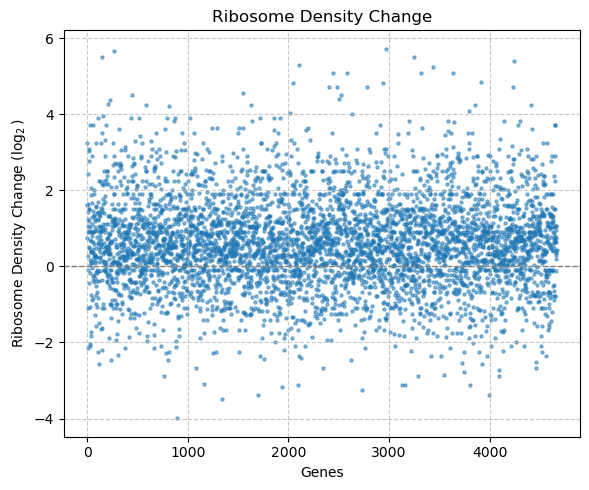

In [135]:
import matplotlib.pyplot as plt

# 🔹 location 정보가 있는 유전자만 사용 + 인덱스 리셋
filtered_df = rden_df[rden_df['location_type'].notna()].copy().reset_index(drop=True)

# 🔹 x축용 인덱스 생성
filtered_df['x'] = filtered_df.index

# 🔹 산점도 그리기
plt.figure(figsize=(6, 5))
plt.scatter(filtered_df['x'], filtered_df['log2_rden_change'], s=5, alpha=0.5)
plt.axhline(0, color='gray', linestyle='--', linewidth=1)

plt.title("Ribosome Density Change")
plt.xlabel("Genes")
plt.ylabel(r"Ribosome Density Change ($\log_2$)")
plt.grid(True, linestyle='--', alpha=0.7)
plt.tight_layout()
plt.show()

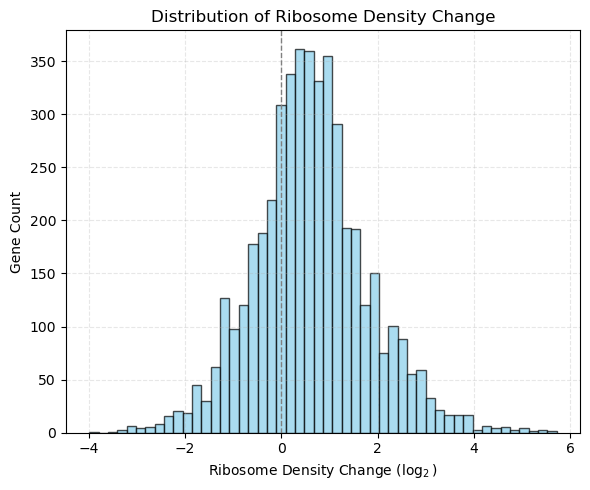

In [139]:
import matplotlib.pyplot as plt
import numpy as np


# 히스토그램
plt.figure(figsize=(6, 5))
plt.hist(filtered_df['log2_rden_change'], bins=50, color='skyblue', edgecolor='black', alpha=0.7)
plt.axvline(0, color='gray', linestyle='--', linewidth=1)
plt.title('Distribution of Ribosome Density Change')
plt.xlabel(r"Ribosome Density Change ($\log_2$)")
plt.ylabel('Gene Count')
plt.grid(True, linestyle='--', alpha=0.3)
plt.tight_layout()
plt.show()

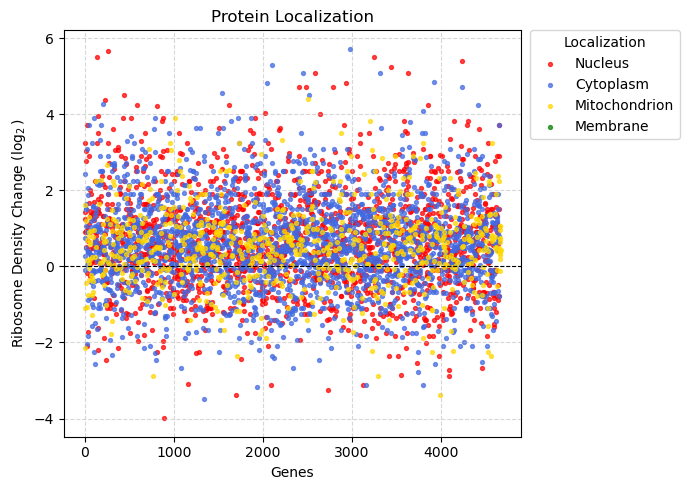

In [145]:
import matplotlib.pyplot as plt
import numpy as np

# 🔹 location 정보 있는 유전자만 선택 & 인덱스 리셋
plot_df = rden_df[rden_df['location_type'].notna()].copy().reset_index(drop=True)

# 🔹 x축용 인덱스 추가
plot_df['x'] = plot_df.index

# 🔹 색상 맵 정의 (localization 그룹)
color_map = {
    'Nucleus': 'red',
    'Cytoplasm': 'royalblue',
    'Mitochondrion': 'gold',
    'Membrane': 'green'
}

# 🔹 시각화 시작
fig, ax = plt.subplots(figsize=(7, 5))

for location, color in color_map.items():
    subset = plot_df[plot_df['location_type'] == location]
    ax.scatter(
        subset['x'], subset['log2_rden_change'],
        s=8, label=location, color=color, alpha=0.7
    )

# 기준선 및 스타일 설정
ax.axhline(0, color='black', linestyle='--', linewidth=0.8)
ax.set_title("Protein Localization")
ax.set_xlabel("Genes")
ax.set_ylabel(r"Ribosome Density Change ($\log_2$)")
ax.grid(True, linestyle='--', alpha=0.5)

# 🔹 legend 바깥에 고정
ax.legend(title='Localization', bbox_to_anchor=(1.02, 1), loc='upper left', borderaxespad=0)
fig.subplots_adjust(right=0.8)  # legend 공간 확보

plt.tight_layout()
plt.show()

In [146]:
from scipy.stats import kruskal

# 그룹별 데이터 분리
groups = rden_df[rden_df['location_type'].notna()].groupby('location_type')['log2_rden_change']

# 그룹별 값 리스트로 추출
group_values = [group.tolist() for name, group in groups]

# Kruskal-Wallis 검정 수행
stat, p = kruskal(*group_values)

print(f"Kruskal–Wallis H = {stat:.3f}, p = {p:.4f}")

Kruskal–Wallis H = 9.067, p = 0.0107


In [150]:
!pip install scikit-posthocs

In [152]:
import scikit_posthocs as sp

# NaN이 없는 행만 사용
filtered_df = rden_df[rden_df['location_type'].notna()]

# 사후 Dunn's test 수행
posthoc = sp.posthoc_dunn(
    filtered_df,
    val_col='log2_rden_change',
    group_col='location_type',
    p_adjust='bonferroni'
)

print(posthoc)

               Cytoplasm  Mitochondrion   Nucleus
Cytoplasm       1.000000       0.779762  0.073276
Mitochondrion   0.779762       1.000000  0.018954
Nucleus         0.073276       0.018954  1.000000


In [142]:
import numpy as np

# 🔹 log2(rden_change) 계산 (혹시 누락된 경우 대비)
if 'log2_rden_change' not in filtered_df.columns:
    filtered_df['log2_rden_change'] = np.log2(filtered_df['rden_change'] + 1e-6)

# 🔹 log2 값 기준으로 상위/하위 유전자 선별
top10 = filtered_df.sort_values('log2_rden_change', ascending=False).head(10)[
    ['symbol', 'log2_rden_change', 'location_type']
]

bottom10 = filtered_df.sort_values('log2_rden_change', ascending=True).head(10)[
    ['symbol', 'log2_rden_change', 'location_type']
]

# 🔹 결과 출력
print("🔺 Top 10 Genes (Most Increased Translation Efficiency):")
print(top10.to_string(index=False, formatters={'log2_rden_change': '{:.2f}'.format}))

print("\n🔻 Bottom 10 Genes (Most Decreased Translation Efficiency):")
print(bottom10.to_string(index=False, formatters={'log2_rden_change': '{:.2f}'.format}))

🔺 Top 10 Genes (Most Increased Translation Efficiency):
symbol log2_rden_change location_type
 Myo1d             5.72     Cytoplasm
 Utp25             5.67       Nucleus
  Med6             5.50       Nucleus
  Mcm6             5.50       Nucleus
  Brd8             5.41       Nucleus
  Scoc             5.31     Cytoplasm
 Med10             5.24       Nucleus
   Ckb             5.08     Cytoplasm
Nufip1             5.08       Nucleus
 Sirt1             5.08       Nucleus

🔻 Bottom 10 Genes (Most Decreased Translation Efficiency):
 symbol log2_rden_change location_type
  Atosb            -3.99       Nucleus
  Hip1r            -3.48     Cytoplasm
   Mpc1            -3.39 Mitochondrion
  Ercc1            -3.37       Nucleus
   Tug1            -3.26       Nucleus
 Dctpp1            -3.16     Cytoplasm
  Kif3c            -3.13     Cytoplasm
Eps15l1            -3.13       Nucleus
Dennd6b            -3.13     Cytoplasm
  Usp36            -3.12       Nucleus
